In [ ]:
# Load Libraries
import pandas as pd
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers
from sklearn.metrics import mean_squared_error
from tensorflow.python.keras.layers import Lambda
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from keras.models import Sequential, Model
from tensorflow.keras.optimizers import RMSprop, Adam
from keras.layers import Dense, LSTM, TimeDistributed, Flatten, Bidirectional, Input
from sklearn.preprocessing import MinMaxScaler
import h5py
import math
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from google.colab import files
from numpy import savetxt

In [ ]:
# Seed
np.random.seed(10)
tf.random.set_seed(10)

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the data
data1 = loadmat('/content/drive/My Drive/Colab Notebooks/PINN_Paper_Codes/New_Models/Reference_p5270/Data/p5270_Data.mat')
data2 = loadmat('/content/drive/My Drive/Colab Notebooks/PINN_Paper_Codes/New_Models/Reference_p5270/Data/p5270MechData.mat')
a_t = pd.DataFrame({'Time':data1['LocalAcTime'].ravel().round(2), 'freqQAmpI_filt':data1['freqQAmpI_filt'].ravel()})
w_t = pd.DataFrame({'Time':data1['LocalAcTime'].ravel().round(2),'C_filt':data1['C_filt'].ravel()})
m_t = pd.DataFrame({'Time':data1['Time'].ravel().round(2), 'SS':data1['SS'].ravel()})
s_t = pd.DataFrame({'Time':data2['Time'].ravel().round(2), 'V':data2['V'].ravel(),'V_filt':data2['V_filt'].ravel()})
df = a_t.merge(w_t, on='Time')
df = df.merge(m_t, on='Time')
df = df.merge(s_t, on='Time')
df = df[['freqQAmpI_filt','Time','SS']]
df_SS = df[['freqQAmpI_filt','SS']]
df_A = df[['freqQAmpI_filt','freqQAmpI_filt']]
xdf = df[['freqQAmpI_filt']]
ydf = df[['SS']]

print("Input Data:\n", xdf)
print("Target Data:\n",ydf)

Input Data:
         freqQAmpI_filt
0         31453.223522
1         31438.277060
2         31421.341616
3         31409.798761
4         31398.815589
...                ...
132394    31055.686766
132395    31041.955345
132396    31035.059531
132397    31020.001291
132398    31012.016780

[132399 rows x 1 columns]
Target Data:
               SS
0       5.656166
1       5.657157
2       5.658317
3       5.659499
4       5.660404
...          ...
132394  5.471059
132395  5.474545
132396  5.478286
132397  5.481751
132398  5.484813

[132399 rows x 1 columns]


In [ ]:
# Split into train-val-test (SS)
x_train_full, x_test_full, y_train_SS_full, y_test_SS_full = train_test_split(xdf, ydf, test_size=0.2, shuffle=False)
X_train_initial, X_val_initial, Y_train_SS_initial, Y_val_SS_initial = train_test_split(x_train_full, y_train_SS_full, test_size=0.125, shuffle=False)

# Select the training data (inputs & outputs) and capture original indices
sp_train = 0
ep_train = 80000
X_train = X_train_initial.iloc[sp_train:ep_train]
Y_train_SS = Y_train_SS_initial.iloc[sp_train:ep_train]
Y_train_SS_time_indices = Y_train_SS.index

# Select the validation data (inputs & outputs) and capture original indices
sp_val = 0
ep_val = 9000
X_val = X_val_initial.iloc[sp_val:ep_val]
Y_val_SS = Y_val_SS_initial.iloc[sp_val:ep_val]
Y_val_SS_time_indices = Y_val_SS.index

# Select the test data (inputs & outputs) and capture original indices
sp_test = 5000
ep_test = 26480 # 26480
x_test = x_test_full.iloc[sp_test:ep_test]
y_test_SS = y_test_SS_full.iloc[sp_test:ep_test]
y_test_SS_time_indices = y_test_SS.index


print("Training samples:", np.shape(X_train)[0])
print("Validation samples:", np.shape(X_val)[0])
print("Testing samples:", np.shape(x_test)[0])

Training samples: 80000
Validation samples: 9000
Testing samples: 21480


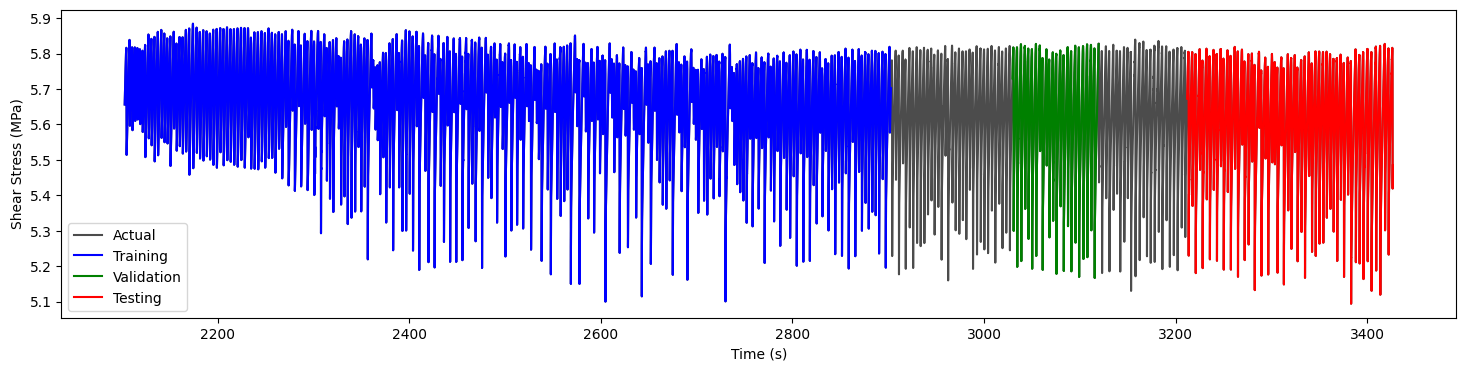

In [ ]:
# Plot data
plt.figure(figsize=(18, 4))
plt.plot(df['Time'], df['SS'], label='Actual', color='black', alpha=0.7)
plt.plot(df['Time'].loc[Y_train_SS.index], Y_train_SS, label='Training', color='blue')
plt.plot(df['Time'].loc[Y_val_SS.index], Y_val_SS, label='Validation', color='green')
plt.plot(df['Time'].loc[y_test_SS.index], y_test_SS, label='Testing', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
# plt.title('Data Splits Over Time')
plt.legend()
plt.show()

In [ ]:
# Normalize the input
scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train))
X_val = pd.DataFrame(scaler.transform(X_val))
x_test = pd.DataFrame(scaler.transform(x_test))

In [ ]:
# Normalize the output
scaler_ss = MinMaxScaler()
Y_train_SS = pd.DataFrame(scaler_ss.fit_transform(Y_train_SS))
Y_val_SS = pd.DataFrame(scaler_ss.transform(Y_val_SS))
y_test_SS = pd.DataFrame(scaler_ss.transform(y_test_SS))

In [ ]:
# Function: Create Data History
def create_timesteps(data, n_steps):
	x = []
	y = []
	for i in range(len(data)-1):
		end_ix = i + n_steps
		if end_ix > len(data)-1:
			break
		x1, y1 = data[i:end_ix, :-1], data[end_ix, -1]
		x.append(x1)
		y.append(y1)
	return np.array(x), np.array(y)

In [ ]:
# Pre process training
combined_train_data = pd.concat([X_train, Y_train_SS], axis=1)
arr_train = combined_train_data.to_numpy()
n_steps = 300
X_train, Y_train_SS = create_timesteps(arr_train, n_steps)

in_dim = X_train.shape[1]*X_train.shape[2]
X_train = X_train.reshape((X_train.shape[0], in_dim))
print('Training Input Shape, X = ', np.shape(X_train))

print('Training Output Shape, Y = ', np.shape(Y_train_SS))

Training Input Shape, X =  (79700, 300)
Training Output Shape, Y =  (79700,)


In [ ]:
# Pre process validation
combined_val_data = pd.concat([X_val, Y_val_SS], axis=1)
arr_val = combined_val_data.to_numpy()
n_steps = 300
X_val, Y_val_SS = create_timesteps(arr_val, n_steps)

in_dim = X_val.shape[1]*X_val.shape[2]
X_val = X_val.reshape((X_val.shape[0], in_dim))
print('Validation Input Shape, X = ', np.shape(X_val))

print('Validation Output Shape, Y = ', np.shape(Y_val_SS))

Validation Input Shape, X =  (8700, 300)
Validation Output Shape, Y =  (8700,)


In [ ]:
# Pre process testing
combined_test_data = pd.concat([x_test, y_test_SS], axis=1)
arr_test = combined_test_data.to_numpy()
n_steps = 300
x_test, y_test_SS = create_timesteps(arr_test, n_steps)

in_dim = x_test.shape[1]*x_test.shape[2]
x_test = x_test.reshape((x_test.shape[0], in_dim))
print('Testing Input Shape, X = ', np.shape(x_test))

print('Testing Output Shape, Y = ', np.shape(y_test_SS))

Testing Input Shape, X =  (21180, 300)
Testing Output Shape, Y =  (21180,)


**Define Data-Driven Model**

In [ ]:
# Define DD
def MLP_Data():

  # Define inputs
  X_train = layers.Input(shape=(300,),name='X_train')

  # Prediction: Shear Stress + Slip Rate
  x = layers.Dense(128,kernel_initializer = 'normal', activation="relu")(X_train)
  x = layers.Dense(64,kernel_initializer = 'normal', activation="relu")(x)
  x = layers.Dense(32,kernel_initializer = 'normal', activation="relu")(x)
  x = layers.Dense(16, kernel_initializer = 'normal', activation="relu")(x)
  x = layers.Dense(8, kernel_initializer = 'normal', activation="relu")(x)
  ss_pred = layers.Dense(1,kernel_initializer = 'normal',activation="linear")(x)

  model = keras.Model(inputs=[X_train],outputs=[ss_pred])
  return model

In [ ]:
# Model Summary
model=MLP_Data()
model.compile(loss='mse', optimizer= tf.keras.optimizers.Adam(1e-3), metrics=['mse'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ X_train (InputLayer)            │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,537 (193.50 KB)

 Trainable params: 49,537 (193.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2484/2491 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0603 - mse: 0.0603
Epoch 1: val_loss improved from None to 0.02117, saving model to /content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Nonconsecutive_Splits/Hand_Crafted_Model/Case_1/Check/Check_10.keras

Epoch 1: finished saving model to /content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Nonconsecutive_Splits/Hand_Crafted_Model/Case_1/Check/Check_10.keras
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.0259 - mse: 0.0259 - val_loss: 0.0212 - val_mse: 0.0212
Epoch 2/100
2489/2491 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0087 - mse: 0.0087
Epoch 2: val_loss improved from 0.02117 to 0.00877, saving model to /content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Nonconsecutive_Splits/Hand_Crafted_Model/Case_1/Check/Check_10.keras

Epoch 2: finished saving model to /content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Nonconsecutive_Splits/Ha

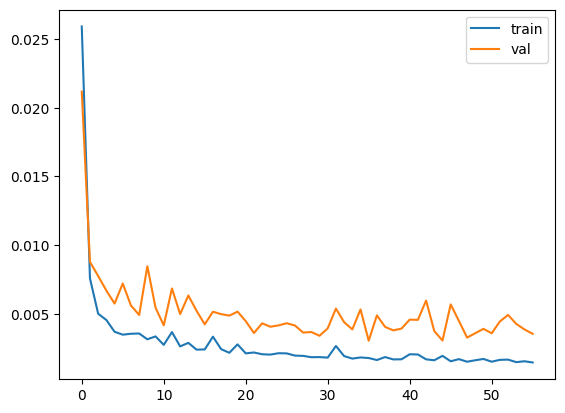

---Training time: 478.23746514 seconds ---


In [ ]:
# Train The Model
earlystop = EarlyStopping(monitor='val_loss', min_delta=0, patience=20,verbose=1, mode='auto')
checkpoint = ModelCheckpoint('/content/drive/My Drive/Colab Notebooks/Final_Features_Extraction_Codes/Nonconsecutive_Splits/Hand_Crafted_Model/Case_1/Check/Check_10.keras', monitor='val_loss', verbose=1, save_best_only=True, mode='min')
callbacks_list = [earlystop, checkpoint]
start_time = time.time()
history = model.fit([X_train],[Y_train_SS], epochs=100, batch_size=32,callbacks=callbacks_list,
                     validation_data=([X_val],[Y_val_SS]), verbose=1)
end_time = time.time()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()
print("---Training time: %0.8f seconds ---" % (end_time - start_time))

In [ ]:
# Model Performance: Training
y_predtrain = model.predict([X_train])
y_predtrain_SS = np.array(y_predtrain)

train_r2_SS = r2_score(Y_train_SS, y_predtrain_SS)
train_rmse_SS = np.sqrt(mean_squared_error(Y_train_SS, y_predtrain_SS))

# Model Performance: Validation
y_predval = model.predict([X_val])
y_predval_SS = np.array(y_predval)

val_r2_SS = r2_score(Y_val_SS, y_predval_SS)
val_rmse_SS = np.sqrt(mean_squared_error(Y_val_SS, y_predval_SS))

# Model Performance: Testing
y_predtest = model.predict([x_test])
y_predtest_SS =np.array(y_predtest)

test_r2_SS = r2_score(y_test_SS,y_predtest_SS)
test_rmse_SS = np.sqrt(mean_squared_error(y_test_SS, y_predtest_SS))

# Print R2 Results
print("R2 scores: Train (SS) - %0.5f" %(train_r2_SS))
print("R2 scores: Validation (SS) - %0.5f" %(val_r2_SS))
print("R2 scores: Testing (SS) - %0.5f" %(test_r2_SS))

2491/2491 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
662/662 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
R2 scores: Train (SS) - 0.94389
R2 scores: Validation (SS) - 0.89951
R2 scores: Testing (SS) - 0.83938


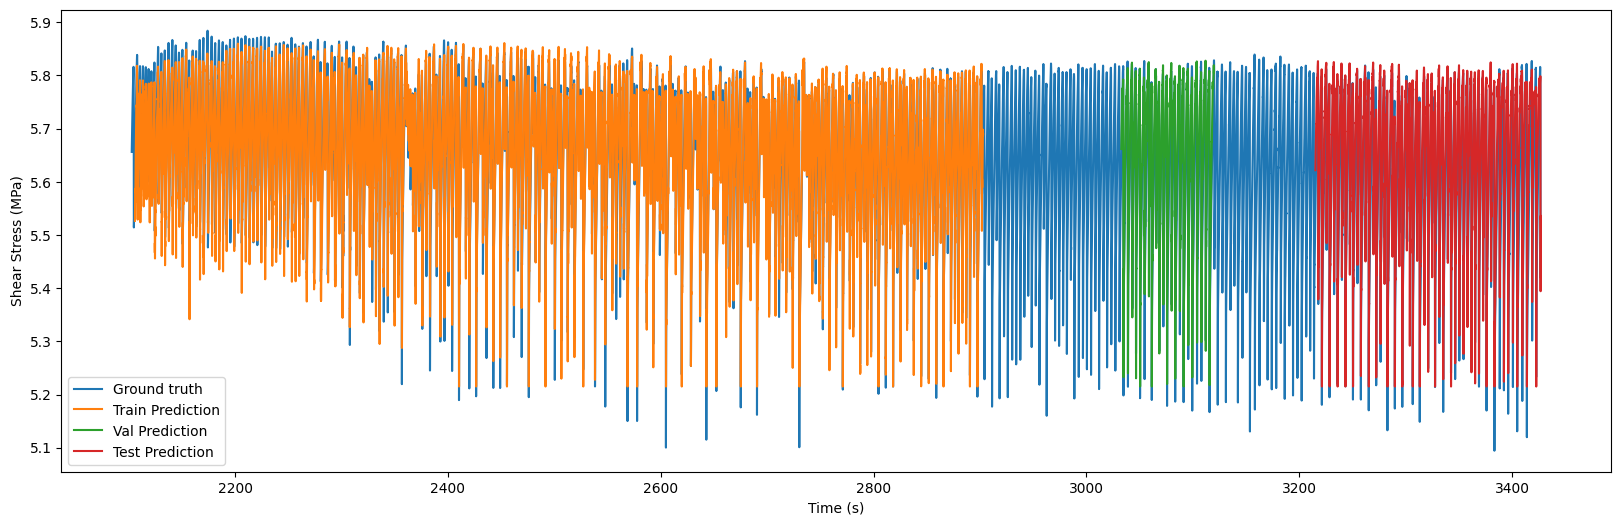

In [ ]:
# Overall plots

# Denormalize the predictions
y_predtrain_SS_denorm = scaler_ss.inverse_transform(y_predtrain_SS)
y_predval_SS_denorm = scaler_ss.inverse_transform(y_predval_SS)
y_predtest_SS_denorm = scaler_ss.inverse_transform(y_predtest_SS)

# Get the actual time indices for the predictions, accounting for n_steps
traintime = df['Time'].loc[Y_train_SS_time_indices[n_steps:]]
valtime = df['Time'].loc[Y_val_SS_time_indices[n_steps:]]
testtime = df['Time'].loc[y_test_SS_time_indices[n_steps:]]

## SS
fig = plt.figure(1, figsize=(20,6))
plt.plot(df['Time'], df['SS'], label='Ground truth') # Plot entire original data as ground truth
plt.plot(traintime, y_predtrain_SS_denorm, label='Train Prediction')
plt.plot(valtime, y_predval_SS_denorm, label='Val Prediction')
plt.plot(testtime, y_predtest_SS_denorm, label='Test Prediction')
plt.xlabel('Time (s)')
plt.ylabel('Shear Stress (MPa)')
# plt.text(df['Time'].iloc[0], 5.3, f'Test R2 Score: {test_r2_SS:.5f}', style='italic', bbox=dict(facecolor='red', alpha=0.5, pad=10))
plt.legend()
# plt.title('Shear Stress Prediction')